In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mariaherrerot/aptos2019")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'aptos2019' dataset.
Path to dataset files: /kaggle/input/aptos2019


In [2]:
import os
import pandas as pd
import numpy as np

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

from PIL import Image
from torchvision import transforms

import timm
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report


In [3]:
IMG_SIZE = 224   # REQUIRED for Swin
NUM_CLASSES = 5
BATCH_SIZE = 16

IMAGE_DIR = "/kaggle/input/aptos2019/train_images/train_images"
CSV_PATH = "/kaggle/input/aptos2019/train_1.csv"

# IMAGE_DIR = "/root/.cache/kagglehub/datasets/mariaherrerot/aptos2019/versions/3/train_images/train_images"
# CSV_PATH = "/root/.cache/kagglehub/datasets/mariaherrerot/aptos2019/versions/3/train_1.csv"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [4]:
df = pd.read_csv(CSV_PATH)
df.head()


,id_code,diagnosis
0,1ae8c165fd53,2
1,1b329a127307,1
2,1b32e1d775ea,4
3,1b3647865779,0
4,1b398c0494d1,0


In [5]:
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["diagnosis"],
    random_state=42
)


In [6]:
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


In [7]:
class APTOSDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        image_id = self.df.loc[idx, "id_code"]
        label = self.df.loc[idx, "diagnosis"]

        img_path = os.path.join(self.image_dir, f"{image_id}.png")
        image = Image.open(img_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        return image, label

In [8]:
train_dataset = APTOSDataset(train_df, IMAGE_DIR, train_transforms)
val_dataset   = APTOSDataset(val_df, IMAGE_DIR, val_transforms)


In [9]:
targets = train_df["diagnosis"].values
class_counts = np.bincount(targets)

class_weights = 1. / class_counts
sample_weights = class_weights[targets]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

In [10]:
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=2
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2
)


In [11]:
model = timm.create_model(
    "swin_base_patch4_window7_224",
    pretrained=True,
    num_classes=NUM_CLASSES
)

model = model.to(device)

# model = timm.create_model(
#     "swin_small_patch4_window7_224",
#     pretrained=True,
#     num_classes=NUM_CLASSES
# )

# model = model.to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/353M [00:00<?, ?B/s]

In [12]:
class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0):
        super().__init__()
        self.gamma = gamma
        self.ce = nn.CrossEntropyLoss()

    def forward(self, inputs, targets):
        logp = self.ce(inputs, targets)
        p = torch.exp(-logp)
        loss = (1 - p) ** self.gamma * logp
        return loss.mean()


In [13]:
criterion = FocalLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode="min", patience=3, factor=0.5
)



In [14]:
def train_one_epoch(model, loader):
    model.train()
    total_loss = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    return total_loss / len(loader)

#

In [15]:
def validate(model, loader):
    model.eval()
    total_loss = 0
    preds, targets = [], []

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            loss = criterion(outputs, labels)
            total_loss += loss.item()

            preds.extend(outputs.argmax(1).cpu().numpy())
            targets.extend(labels.cpu().numpy())

    return total_loss / len(loader), targets, preds

In [16]:
import gc
torch.cuda.empty_cache()
gc.collect()

EPOCHS = 10

for epoch in range(EPOCHS):
    train_loss = train_one_epoch(model, train_loader)
    val_loss, y_true, y_pred = validate(model, val_loader)

    scheduler.step(val_loss)

    print(f"Epoch {epoch+1}/{EPOCHS}")
    print(f"Train Loss: {train_loss:.4f}")
    print(f"Val Loss:   {val_loss:.4f}")


Epoch 1/15
Train Loss: 0.4369
Val Loss:   0.1062
Epoch 2/15
Train Loss: 0.1828
Val Loss:   0.1010
Epoch 3/15
Train Loss: 0.1020
Val Loss:   0.1019
Epoch 4/15
Train Loss: 0.0576
Val Loss:   0.1309
Epoch 5/15
Train Loss: 0.0333
Val Loss:   0.2075
Epoch 6/15
Train Loss: 0.0245
Val Loss:   0.1257
Epoch 7/15
Train Loss: 0.0095
Val Loss:   0.1594
Epoch 8/15
Train Loss: 0.0057
Val Loss:   0.1616
Epoch 9/15
Train Loss: 0.0031
Val Loss:   0.1783
Epoch 10/15
Train Loss: 0.0016
Val Loss:   0.2068
Epoch 11/15
Train Loss: 0.0016
Val Loss:   0.2159
Epoch 12/15
Train Loss: 0.0010
Val Loss:   0.2165
Epoch 13/15
Train Loss: 0.0010
Val Loss:   0.2264
Epoch 14/15
Train Loss: 0.0010
Val Loss:   0.2108
Epoch 15/15
Train Loss: 0.0010
Val Loss:   0.2258


In [17]:
print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       1.00      0.96      0.98       287
           1       0.78      0.67      0.72        60
           2       0.77      0.89      0.83       161
           3       0.61      0.55      0.58        31
           4       0.83      0.74      0.79        47

    accuracy                           0.87       586
   macro avg       0.80      0.76      0.78       586
weighted avg       0.88      0.87      0.87       586



In [ ]:
# Save Swin-Small model checkpoint
torch.save({
    "model_state_dict": model.state_dict(),   # model weights
    "num_classes": NUM_CLASSES,               # number of output classes
    "model_name": "swin_base_patch4_window7_224",  # architecture name
    "class_mapping": {
        0: "No_DR",
        1: "Mild",
        2: "Moderate",
        3: "Severe",
        4: "Proliferative"
    }
}, "swin_base_patch4_window7_224")

print("✅ Model saved successfully! ")



✅ Model saved successfully!


In [19]:
import torch
import timm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load checkpoint
checkpoint = torch.load("swin_base_patch4_window7_224", map_location=device)

# Re-create the exact same Swin-Small model
model = timm.create_model(
    checkpoint["model_name"],  # must match the saved architecture
    pretrained=False,
    num_classes=checkpoint["num_classes"]
)

# Load weights
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()
model.to(device)

# Optional: get class mapping
class_mapping = checkpoint["class_mapping"]

print("✅ Model loaded successfully!")



✅ Model loaded successfully!


In [20]:
from PIL import Image
from torchvision import transforms

# Define preprocessing same as training
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

def predict_image(image_path):
    image = Image.open(image_path).convert("RGB")
    image = transform(image).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = model(image)
        pred_class_idx = torch.argmax(outputs, dim=1).item()
        pred_class_name = class_mapping[pred_class_idx]

    return pred_class_name


In [21]:
predict_image("/kaggle/input/aptos2019/val_images/val_images/00e4ddff966a.png")

'Moderate'

In [34]:
predict_image("/content/Screenshot 2026-01-29 140014.png")

'Proliferative'

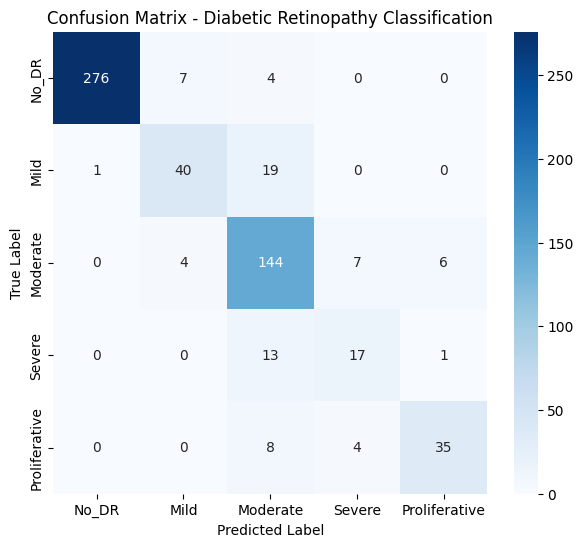

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

class_names = [
    "No_DR",
    "Mild",
    "Moderate",
    "Severe",
    "Proliferative"
]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Diabetic Retinopathy Classification")
plt.show()


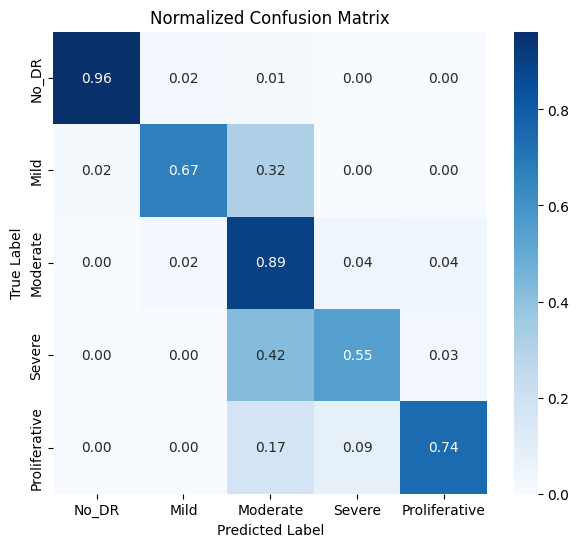

In [27]:
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Normalized Confusion Matrix")
plt.show()


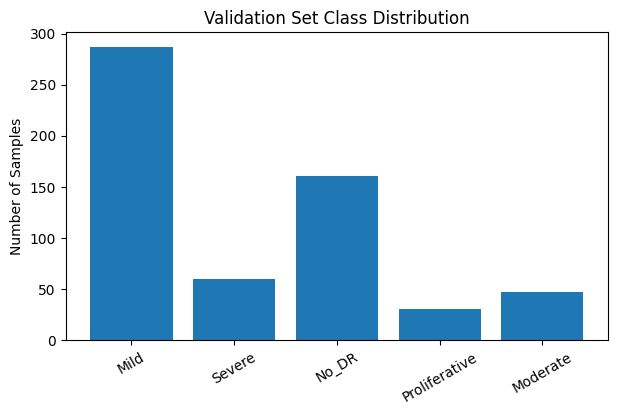

In [28]:
import collections

counter = collections.Counter(y_true)

plt.figure(figsize=(7, 4))
plt.bar(counter.keys(), counter.values())
plt.xticks(list(counter.keys()), class_names, rotation=30)
plt.ylabel("Number of Samples")
plt.title("Validation Set Class Distribution")
plt.show()


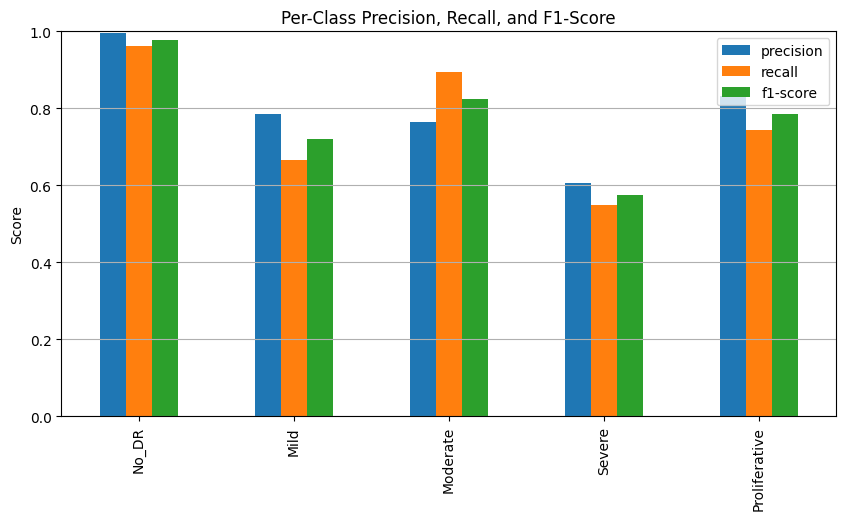

In [29]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    output_dict=True
)

df_report = pd.DataFrame(report).transpose()
df_report = df_report.iloc[:-3]  # remove avg rows

df_report[["precision", "recall", "f1-score"]].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Per-Class Precision, Recall, and F1-Score")
plt.ylabel("Score")
plt.ylim(0, 1.0)
plt.grid(axis="y")
plt.show()
